In [1]:
# import relevant packages
# note: if scanpy doesn't load, you'll need to re-open this within the scanpy kernal: 
import sys
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from anndata import AnnData
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import monkeybread as mb
import glasbey

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing 

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [5]:
adata1 = sc.read_h5ad(r"D:\BT\ecEGFR\sc_objects\20250819_ecEGFR_xenograft_human_5.h5ad")

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


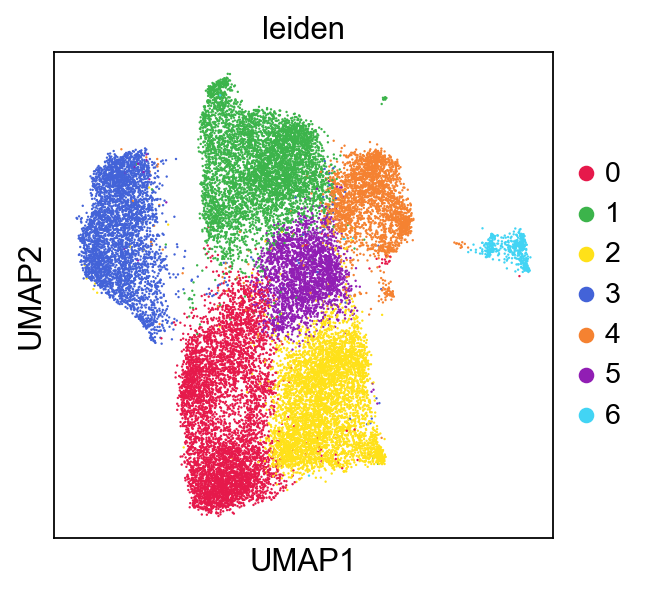

In [6]:
sc.pl.umap(adata1, color = 'leiden')

In [7]:
### Calling GBM states on single cell scores, which were derived from Neftel et al. 

In [11]:
# 1) define your four state gene lists 
signatures = {
    "AC":  ['AGT',
  'ANXA5',
  'AQP4',
  'ATP1A2',
  'ATP1B2',
  'BCAN',
  'CLU',
  'CST3',
  'DBI',
  'EDNRB',
  'F3',
  'FABP7',
  'GATM',
  'GFAP',
  'GPM6B',
  'HEPN1',
  'HEY1',
  'HOPX',
  'METTL7B',
  'MLC1',
  'MT3',
  'NDRG2',
  'PCDHGC3',
  'PLTP',
  'PMP2',
  'PMP22',
  'PON2',
  'PPAP2B',
  'PRCP',
  'PTPRZ1',
  'RAB31',
  'RAMP1',
  'S100A16',
  'S100B',
  'SLC1A3',
  'SPARC',
  'SPARCL1',
  'TSPAN7',
  'TTYH1'], 
    "MES": ['A2M',
  'ACTN1',
  'ADM',
  'AKAP12',
  'ANGPTL4',
  'ANXA1',
  'ANXA2',
  'APOE',
  'ASNS',
  'ATF3',
  'BNIP3',
  'BNIP3L',
  'C1R',
  'C1S',
  'C3',
  'C8ORF4',
  'CA9',
  'CD44',
  'CDKN1A',
  'CHI3L1',
  'CLIC1',
  'CLIC4',
  'CTSB',
  'DDIT3',
  'DNAJB9',
  'EFEMP1',
  'EGLN3',
  'EMP1',
  'EMP3',
  'ENO2',
  'EPAS1',
  'ERO1L',
  'FN1',
  'FTL',
  'GBE1',
  'GDF15',
  'GFPT2',
  'GJA1',
  'GOLT1B',
  'GSN',
  'HERPUD1',
  'HILPDA',
  'HSPA5',
  'HSPA9',
  'IFITM3',
  'IGFBP3',
  'IGFBP7',
  'INSIG2',
  'LDHA',
  'LGALS1',
  'LGALS3',
  'MGP',
  'MGST1',
  'MT1E',
  'MT1X',
  'MT2A',
  'NAMPT',
  'NDRG1',
  'NNMT',
  'NPC2',
  'NRN1',
  'P4HA1',
  'PFKP',
  'PGK1',
  'PLOD2',
  'PLP2',
  'PPP1R15A',
  'PRDX6',
  'RCAN1',
  'RPL21',
  'S100A10',
  'S100A11',
  'S100A16',
  'SERPINA3',
  'SERPINE1',
  'SERPING1',
  'SERTAD1',
  'SLC2A1',
  'SLC2A3',
  'SLC39A14',
  'SLC6A6',
  'SOD2',
  'SPP1',
  'SQSTM1',
  'TAGLN2',
  'TIMP1',
  'TNFRSF1A',
  'TRAM1',
  'TRIB3',
  'TUBA1C',
  'UFM1',
  'VIM',
  'WARS',
  'WWTR1',
  'XPOT'],
    "OPC": ['ALCAM',
  'APOD',
  'BCAN',
  'BCAS1',
  'CA10',
  'CADM2',
  'CNP',
  'CNTN1',
  'DBI',
  'EPB41L2',
  'FABP5',
  'FGF12',
  'FIBIN',
  'FXYD6',
  'GPM6B',
  'GPR17',
  'GPR37L1',
  'HRASLS',
  'LHFPL3',
  'LIMA1',
  'LMF1',
  'LPPR1',
  'NEU4',
  'NKAIN4',
  'NLGN3',
  'OLIG1',
  'OMG',
  'P2RX7',
  'PCDHGC3',
  'PGRMC1',
  'PHYHIPL',
  'PLLP',
  'PLP1',
  'PMP2',
  'PSAT1',
  'PTPRZ1',
  'RAB31',
  'RNF13',
  'RTKN',
  'SCD5',
  'SCRG1',
  'SERINC5',
  'SIRT2',
  'SOX2-OT',
  'THY1',
  'TMEM206',
  'TNR',
  'TNS3',
  'TTYH1',
  'VCAN'],
    "NPC": ['ABAT',
  'AMOTL2',
  'ASCL1',
  'ATP1B1',
  'BCAN',
  'BEX1',
  'BLCAP',
  'BTG2',
  'CD200',
  'CD24',
  'CEP170',
  'CHD7',
  'CRABP1',
  'DBN1',
  'DCX',
  'DDAH2',
  'DLL1',
  'DLL3',
  'DLX5',
  'DLX6-AS1',
  'DPYSL3',
  'DPYSL5',
  'DYNC1I1',
  'ELAVL4',
  'ELMO1',
  'ENO2',
  'ETV1',
  'FNBP1L',
  'FXYD6',
  'GLCCI1',
  'GNG3',
  'GPR56',
  'GRIK2',
  'HES6',
  'HIP1',
  'HMP19',
  'HN1',
  'IGFBPL1',
  'KIF5A',
  'KIF5C',
  'LBH',
  'LMF1',
  'LOC150568',
  'LRRN1',
  'MAP1B',
  'MAP2',
  'MARCKSL1',
  'MEST',
  'MIAT',
  'MLLT11',
  'MYT1',
  'NDRG4',
  'NEU4',
  'NFIB',
  'NFIX',
  'NPPA',
  'NREP',
  'NSG1',
  'NXPH1',
  'OLIG1',
  'PAK3',
  'PCBP4',
  'PFN2',
  'PKIA',
  'PTPRS',
  'RBFOX2',
  'RND3',
  'SCG3',
  'SEPTIN3',
  'SERINC5',
  'SEZ6',
  'SEZ6L',
  'SHD',
  'SNAP25',
  'SOX11',
  'SOX4',
  'STMN1',
  'STMN2',
  'STMN4',
  'TAGLN3',
  'TCF12',
  'TCF4',
  'TMEM161B-AS1',
  'TNR',
  'TSPAN13',
  'TUBA1A',
  'TUBB2A',
  'TUBB3',
  'UCHL1']
}

In [12]:
# this contains a bunch of script used to call states

import sys
sys.path.append(r'D:\BT\ecEGFR\notebooks\MERFISH\GBM39\mouse_replicates\scripts')
from neftel_butterfly_pipeline import *

In [16]:
signatures

{'AC': ['AGT',
  'ANXA5',
  'AQP4',
  'ATP1A2',
  'ATP1B2',
  'BCAN',
  'CLU',
  'CST3',
  'DBI',
  'EDNRB',
  'F3',
  'FABP7',
  'GATM',
  'GFAP',
  'GPM6B',
  'HEPN1',
  'HEY1',
  'HOPX',
  'METTL7B',
  'MLC1',
  'MT3',
  'NDRG2',
  'PCDHGC3',
  'PLTP',
  'PMP2',
  'PMP22',
  'PON2',
  'PPAP2B',
  'PRCP',
  'PTPRZ1',
  'RAB31',
  'RAMP1',
  'S100A16',
  'S100B',
  'SLC1A3',
  'SPARC',
  'SPARCL1',
  'TSPAN7',
  'TTYH1'],
 'MES': ['A2M',
  'ACTN1',
  'ADM',
  'AKAP12',
  'ANGPTL4',
  'ANXA1',
  'ANXA2',
  'APOE',
  'ASNS',
  'ATF3',
  'BNIP3',
  'BNIP3L',
  'C1R',
  'C1S',
  'C3',
  'C8ORF4',
  'CA9',
  'CD44',
  'CDKN1A',
  'CHI3L1',
  'CLIC1',
  'CLIC4',
  'CTSB',
  'DDIT3',
  'DNAJB9',
  'EFEMP1',
  'EGLN3',
  'EMP1',
  'EMP3',
  'ENO2',
  'EPAS1',
  'ERO1L',
  'FN1',
  'FTL',
  'GBE1',
  'GDF15',
  'GFPT2',
  'GJA1',
  'GOLT1B',
  'GSN',
  'HERPUD1',
  'HILPDA',
  'HSPA5',
  'HSPA9',
  'IFITM3',
  'IGFBP3',
  'IGFBP7',
  'INSIG2',
  'LDHA',
  'LGALS1',
  'LGALS3',
  'MGP',
  'MGST

In [17]:
# signatures = {"AC":[...], "MES":[...], "OPC":[...], "NPC":[...]}
sigs = filter_signatures_to_var(adata1, signatures, use_raw=False)

[AC] kept 18 (missing: 21, zero/const filtered: 0)
[MES] kept 22 (missing: 73, zero/const filtered: 0)
[OPC] kept 15 (missing: 35, zero/const filtered: 0)
[NPC] kept 21 (missing: 68, zero/const filtered: 0)


In [32]:
# Can play with the number of bins (n_bins) and number of genes per bin (n), which is used for the control gene set.
# 10 and 15 were used because we have 343 genes total.

scores = score_anndata(adata1, sigs, n_bins=10, n=15, replace=True, prefix="Neftel_")
df = adata1.obs[["Neftel_AC","Neftel_MES","Neftel_OPC","Neftel_NPC"]].rename(
    columns={"Neftel_AC":"AC","Neftel_MES":"MES","Neftel_OPC":"OPC","Neftel_NPC":"NPC"}
)

In [33]:
H = compute_butterfly(df)

In [34]:
adata1.obs["butterfly_X"] = H["X"].values
adata1.obs["butterfly_Y"] = H["Y"].values

In [35]:
assign_neftel_state(adata1)

Conv_zscan__276_27600578    MES
Conv_zscan__276_27600645    MES
Conv_zscan__276_27600717    MES
Conv_zscan__276_27701143    MES
Conv_zscan__277_27600919    MES
                           ... 
Conv_zscan__314_31500128    MES
Conv_zscan__314_31500237    MES
Conv_zscan__314_31500264    MES
Conv_zscan__314_31500409    MES
Conv_zscan__314_31500606    MES
Name: Neftel_state, Length: 26063, dtype: category
Categories (5, object): ['AC', 'MES', 'OPC', 'NPC', 'Ambiguous']

<Axes: xlabel='Butterfly X', ylabel='Butterfly Y'>

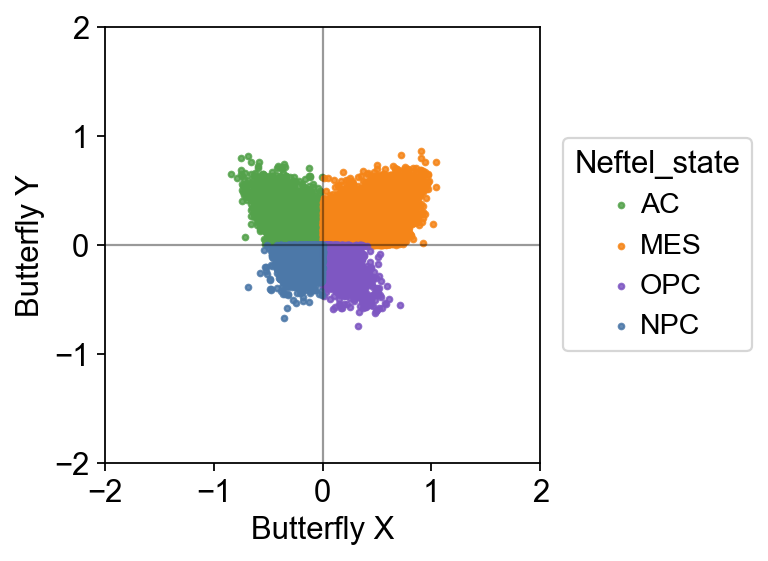

In [36]:
plot_butterfly_scatter(adata1)

In [23]:
# Because of the lower number of genes (343) vs. scRNA seq experiments, there may be some fluctuation with assignments based on the control geneset.
# can repeat scoring and look at cells that change states to understand confidence with classifications.

out = bootstrap_cellwise_neftel(adata1, sigs, n_boot=50, n_bins=10, n=15, replace=True)

<Axes: xlabel='Butterfly X (boot mean)', ylabel='Butterfly Y (boot mean)'>

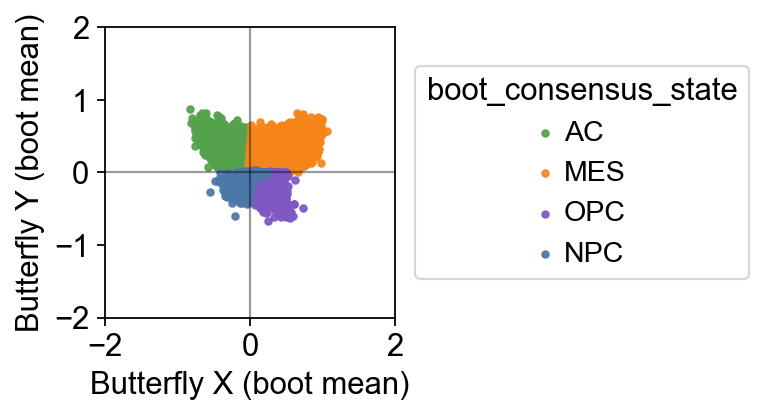

In [25]:
plot_bootstrap_consensus_scatter(adata1)

In [37]:
adata1.obs["Neftel_state"].value_counts()

Neftel_state
MES          16164
AC            4116
NPC           3139
OPC           2644
Ambiguous        0
Name: count, dtype: int64

In [38]:
adata1.obs["boot_consensus_state"].value_counts()

boot_consensus_state
MES    16226
AC      4493
OPC     3999
NPC     1345
Name: count, dtype: int64

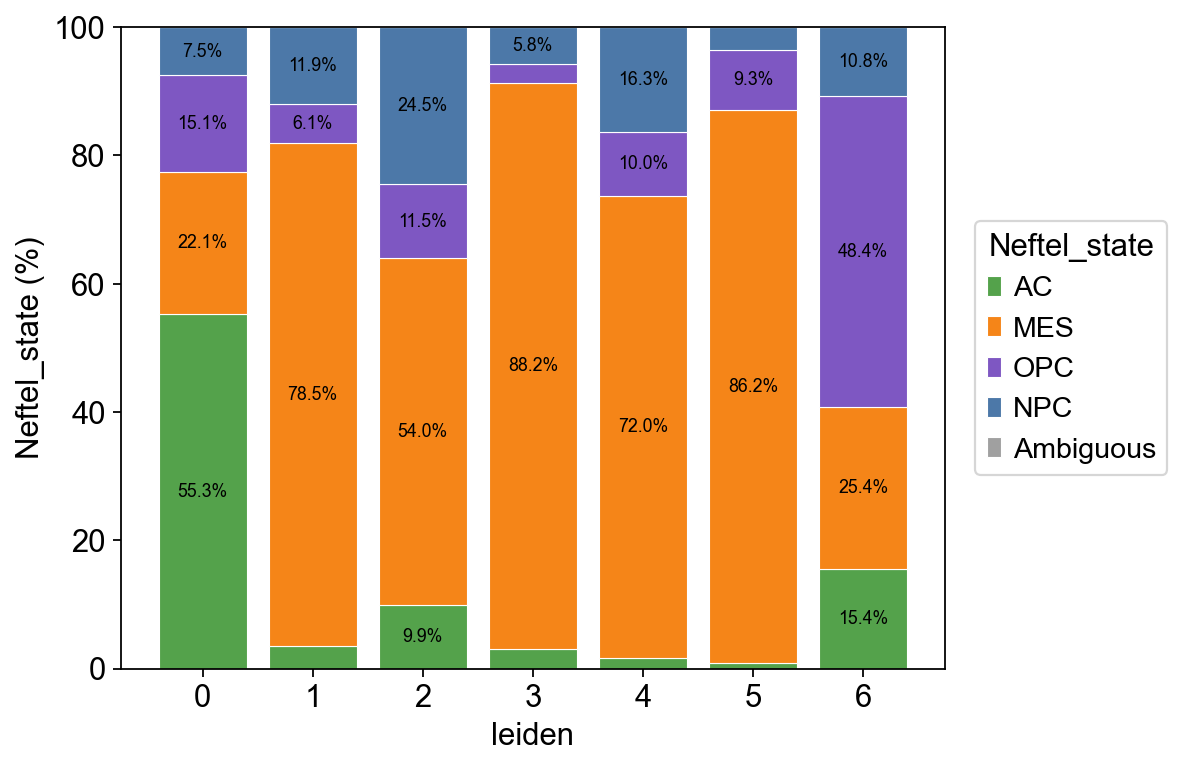

In [39]:
# Example: for one round of score calling
ax, pct_tbl = stacked_percentage_bar(
    adata1,
    x_col="leiden",            # any .obs column works here
    y_col="Neftel_state",      # the categorical you want stacked
    y_order=["AC","MES","OPC","NPC","Ambiguous"],
    sort_x_by="name",          # or "count" or None
    show_labels=True,          # prints % inside segments
    label_fmt="{p:.1f}%",      # formatting for labels
)

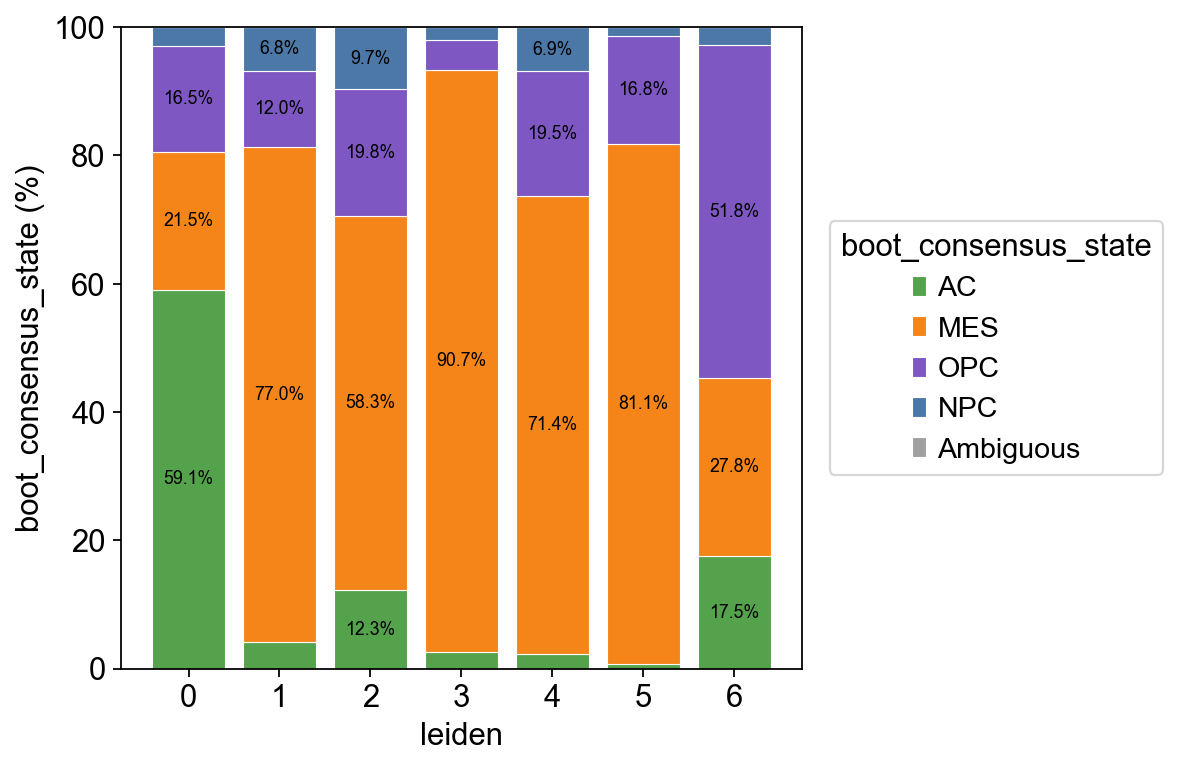

In [41]:
# Example: for one round boot-strapping calling...Overall, relatively consistent with some fluctuation. 
# Overall: 0_AC, 6_OPC, and the rest are MES, which is how we classified in the paper. 
ax, pct_tbl = stacked_percentage_bar(
    adata1,
    x_col="leiden",            # any .obs column works here
    y_col="boot_consensus_state",      # the categorical you want stacked
    y_order=["AC","MES","OPC","NPC","Ambiguous"],
    sort_x_by="name",          # or "count" or None
    show_labels=True,          # prints % inside segments
    label_fmt="{p:.1f}%",      # formatting for labels
)

In [42]:
# Can also set a threshold based on switching and label cells as ambiguous.

In [44]:
# mark cells with confidence < 0.9 as ambiguous
mark_ambiguous_by_conf(adata1, threshold=0.9)

Conv_zscan__276_27600578    False
Conv_zscan__276_27600645    False
Conv_zscan__276_27600717    False
Conv_zscan__276_27701143    False
Conv_zscan__277_27600919    False
                            ...  
Conv_zscan__314_31500128    False
Conv_zscan__314_31500237     True
Conv_zscan__314_31500264     True
Conv_zscan__314_31500409    False
Conv_zscan__314_31500606    False
Name: boot_consensus_conf, Length: 26063, dtype: bool

<Axes: xlabel='Butterfly X', ylabel='Butterfly Y'>

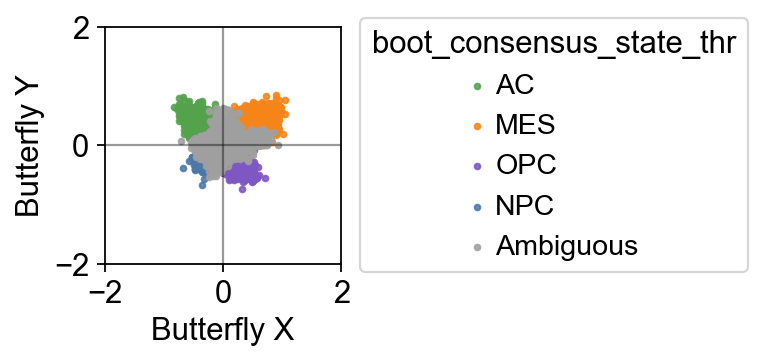

In [45]:
plot_butterfly_scatter(adata1, state_col = "boot_consensus_state_thr")

In [51]:
adata1.obs["boot_consensus_state_thr"].value_counts()

boot_consensus_state_thr
MES          13213
Ambiguous     7346
AC            3232
OPC           1893
NPC            379
Name: count, dtype: int64

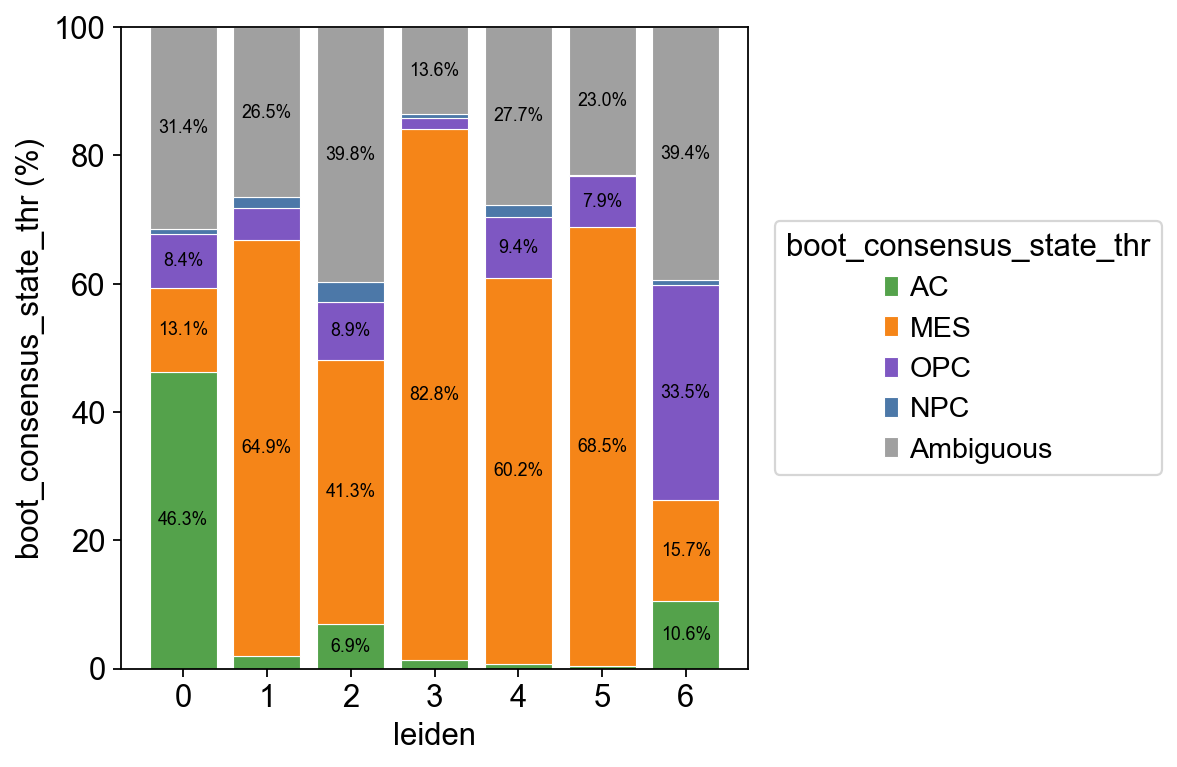

In [46]:
# Example: proportions of Neftel states across leiden clusters
ax, pct_tbl = stacked_percentage_bar(
    adata1,
    x_col="leiden",            # any .obs column works here
    y_col="boot_consensus_state_thr",      # the categorical you want stacked
    y_order=["AC","MES","OPC","NPC","Ambiguous"],
    sort_x_by="name",          # or "count" or None
    show_labels=True,          # prints % inside segments
    label_fmt="{p:.1f}%",      # formatting for labels
)

In [47]:
# This makes it even clearer that the dominant states in that cluster are more confidently called 
# whereas the NPC-like cells are likely called moreso due to noise/technical reasons.

In [49]:
import pandas as pd
import numpy as np

def add_butterfly_state_cluster(
    adata,
    cluster_col="leiden",                  # source Leiden cluster column
    new_col="butterfly_state_cluster"
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"'{cluster_col}' not found in adata.obs")

    # Your mapping by Leiden cluster index
    cluster_to_state = {
        0: "0_AC",
        1: "1_MES",
        2: "2_MES",
        3: "3_MES",
        4: "4_MES",
        5: "5_MES",
        6: "6_OPC",
    }

    # Handle common Leiden formats (often strings like "0","1",… and categorical dtype)
    col = adata.obs[cluster_col]

    # Convert to numeric cluster index when possible
    # (strings like "0" -> 0; anything non-numeric becomes NaN then unmapped)
    cluster_idx = pd.to_numeric(pd.Series(col.astype(str).values, index=col.index), errors="coerce")

    # Map to state labels
    mapped = cluster_idx.map(cluster_to_state)

    # Anything not in the mapping becomes "Unlabeled"
    mapped = mapped.fillna("Unlabeled")

    # Make it a tidy categorical (you can tweak order if you prefer)
    cats = ["0_AC", "1_MES", "2_MES", "3_MES","4_MES","5_MES","6_OPC",]
    mapped = pd.Categorical(mapped, categories=cats, ordered=False)

    adata.obs[new_col] = mapped

    # Optional: quick sanity prints (comment out if running non-interactively)
    print(f"Added '{new_col}' from '{cluster_col}'.")
    print(adata.obs[new_col].value_counts(dropna=False))

# --- run it ---
add_butterfly_state_cluster(adata1, cluster_col="leiden", new_col="butterfly_state_cluster")

Added 'butterfly_state_cluster' from 'leiden'.
butterfly_state_cluster
0_AC     5702
1_MES    5538
2_MES    5065
3_MES    4012
4_MES    2636
5_MES    2618
6_OPC     492
Name: count, dtype: int64


C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


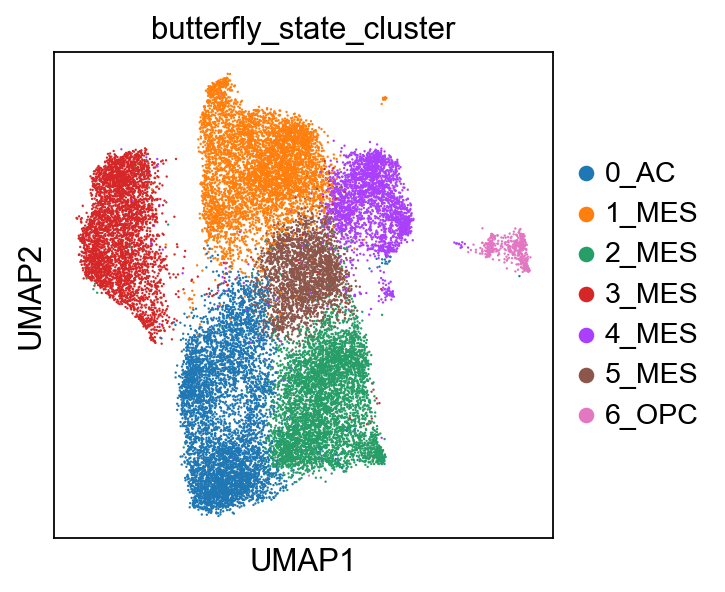

In [50]:
sc.pl.umap(adata1, color = "butterfly_state_cluster")